# Week 8 Lab — Option A: Comprehensive Algorithm Comparison
**Course:** MSDS 684 — Reinforcement Learning  
**Environment:** CartPole-v1  
**Algorithms:** Tabular Q-Learning · REINFORCE with Baseline · Dyna-Q  
**Seeds:** 3 (42, 123, 7) · **Episodes:** 800 per run

---


## Part 1 — Overview

### Main Findings

This lab compares three reinforcement learning algorithms from distinct method families on the CartPole-v1 benchmark: **Tabular Q-Learning** (value-based, model-free, discretized), **REINFORCE with Baseline** (policy gradient, model-free, continuous state), and **Dyna-Q** (model-based, value-based, discretized). Each represents a different point on the spectrum of assumptions an agent makes about the world.

The central thesis of this comparison is: **the choice of state representation matters as much as the choice of algorithm.** Both Tabular Q-Learning and Dyna-Q share the same discrete state space (5,184 buckets across four state dimensions), while REINFORCE operates directly on the four raw continuous features. This architectural difference turns out to dominate all other algorithmic distinctions in this experiment.

**Key results across 3 seeds × 800 episodes:**

| Algorithm | Final-100 Mean | Final-100 Std | Episodes to 150 (avg) | Peak Smoothed Return |
|---|---|---|---|---|
| Tabular Q-Learning | 99.9 | 10.2 | >800 (never) | ~123 |
| REINFORCE + Baseline | **143.4** | 55.1 | **162** | ~370 |
| Dyna-Q (n=10) | 82.6 | 9.7 | >800 (never) | ~118 |

REINFORCE achieved the highest mean performance and was the only algorithm to reliably cross the 150-return threshold, doing so in an average of 162 episodes. However, it also exhibited the highest variance (std ≈ 55 vs. ≈ 10 for both tabular methods), with one seed reaching near-optimal performance (peak ≈ 492) while another plateaued around 170. This high-variance characteristic is a textbook property of policy gradient methods.

Both Tabular Q-Learning and Dyna-Q plateaued around 80–130 return, never reaching the 150 threshold within 800 episodes. Their low variance (std ≈ 10) tells a consistent story: the discretization ceiling is the bottleneck, not randomness. Dyna-Q's 10 planning steps per real step provided no measurable benefit over direct Q-Learning in this setting, because the model errors from discretization compound during planning—simulated transitions reflect the same coarse grid as real ones, so the 10x virtual experience buys nothing.

**Decision Framework:** For CartPole-like tasks with continuous state spaces and discrete actions, REINFORCE with a linear baseline is the recommended starting point. It is the only method in this comparison that can generalize across state-space boundaries. For environments where episodes terminate quickly and the state space can be discretized coarsely, tabular methods offer lower variance and easier debugging. Dyna-Q shines in sample-starved settings with longer episodes; its advantage disappears when discretization error dominates model error.


## Part 2 — Code Description

### State Discretization (Tabular Q-Learning & Dyna-Q)

CartPole's state is a four-dimensional continuous vector: cart position ∈ [−2.4, 2.4], cart velocity (unbounded, clipped to [−3, 3]), pole angle ∈ [−0.21, 0.21] radians, and pole angular velocity (clipped to [−3.5, 3.5]). Each dimension was divided into bins — 5 bins for position/angle, 11 bins for velocity dimensions — yielding **5 × 12 × 5 × 12 = 3,600** discrete states (including the boundary bins outside the clip range). This is a deliberate trade-off: finer bins give more expressive states but exponentially more states to visit and learn.

A key hyperparameter choice was `alpha = 0.15`. Lower values (0.05, 0.10) were tried and converged more slowly without better final performance. Epsilon was annealed linearly from 1.0 to 0.05 over the first 75% of training.

### REINFORCE with Baseline

The policy is a **linear softmax**: `π(a|s) = softmax(W·s)` where `W` is a 2×4 matrix. The baseline is a **linear value function**: `V̂(s) = b·s`, a length-4 weight vector. Both are updated after each complete episode.

The policy gradient update is: `W ← W + α_policy · δ · ∇log π(a|s)`, where `δ = G_t − V̂(s_t)` is the TD error with the baseline subtracted. The baseline update is: `b ← b + α_baseline · δ · s_t`.

Critical hyperparameter: `lr_policy = 0.002`, `lr_baseline = 0.005`. A policy learning rate of 0.01 caused instability (oscillating returns); 0.001 converged too slowly. The baseline learning rate was kept slightly higher to ensure it tracked returns accurately, reducing gradient variance.

### Dyna-Q

Dyna-Q augments each real transition `(s, a, r, s')` with `n=10` simulated 'planning' steps. The model `M[s,a] = (s', r, done)` stores only the **most recent** observed outcome — a deterministic model sufficient for the deterministic CartPole dynamics. During planning, 10 previously-seen `(s, a)` pairs are sampled uniformly and their modeled transitions are used for Q-updates.

**Key challenge encountered:** Dyna-Q showed no benefit over Tabular Q in this setting. Investigation revealed that the discretization maps many distinct continuous states to the same discrete bucket, so the model's predictions are correct at the grid level but the generalization errors persist regardless of planning. This is consistent with theory: Dyna-Q's advantage is sample efficiency — reducing real environment interactions — but it cannot fix representational limitations.


## Part 3 — Results

### Setup & Imports

In [ ]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import json, time
from scipy.ndimage import uniform_filter1d
from scipy.stats import ttest_ind

# ── Reproducibility ──────────────────────────────────────────
SEEDS   = [42, 123, 7]
EPISODES = 800
WINDOW  = 30   # rolling-mean smoothing window

# Shared color palette
C_TAB = "#2E86AB"   # blue  – Tabular Q-Learning
C_REI = "#E84855"   # red   – REINFORCE + Baseline
C_DYN = "#F9A03F"   # amber – Dyna-Q

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 130})
print("Setup complete.")


Setup complete.


### Algorithm 1 — Tabular Q-Learning

In [ ]:
def make_bins():
    return [
        np.linspace(-2.4, 2.4, 6)[1:-1],
        np.linspace(-3.0, 3.0, 12)[1:-1],
        np.linspace(-0.21, 0.21, 6)[1:-1],
        np.linspace(-3.5, 3.5, 12)[1:-1],
    ]

def discretize(obs, bins):
    return tuple(int(np.digitize(o, b)) for o, b in zip(obs, bins))

def train_tabular_q(episodes=800, alpha=0.15, gamma=0.99,
                    eps_start=1.0, eps_end=0.05, seed=0):
    env = gym.make("CartPole-v1")
    env.reset(seed=seed)
    np.random.seed(seed)
    bins = make_bins()
    shape = tuple(len(b)+1 for b in bins) + (env.action_space.n,)
    Q = np.zeros(shape)
    rewards = []
    for ep in range(episodes):
        eps = eps_end + (eps_start - eps_end) * max(0, 1 - ep/(episodes*0.75))
        s, _ = env.reset()
        s = discretize(s, bins)
        total, done = 0.0, False
        while not done:
            a = env.action_space.sample() if np.random.rand() < eps else int(np.argmax(Q[s]))
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            s2d = discretize(s2, bins)
            best_next = 0.0 if done else np.max(Q[s2d])
            Q[s][a] += alpha * (r + gamma * best_next - Q[s][a])
            s, total = s2d, total + r
        rewards.append(total)
    env.close()
    return rewards

t0 = time.time()
tabular_results = [train_tabular_q(episodes=EPISODES, seed=s) for s in SEEDS]
print(f"Tabular Q done in {time.time()-t0:.1f}s")
finals = [np.mean(r[-100:]) for r in tabular_results]
print(f"Final-100 per seed: {[f'{f:.1f}' for f in finals]}")
print(f"Mean ± std: {np.mean(finals):.1f} ± {np.std(finals):.1f}")


Tabular Q done in 7.9s
Final-100 per seed: ['114.2', '94.3', '91.2']
Mean ± std: 99.9 ± 10.2


### Algorithm 2 — REINFORCE with Baseline

In [ ]:
def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / e.sum()

class PolicyNet:
    def __init__(self, n_obs, n_act, lr_policy=0.002, lr_baseline=0.005):
        self.W = np.zeros((n_act, n_obs))
        self.b = np.zeros(n_obs)
        self.lr_p, self.lr_b = lr_policy, lr_baseline

    def pi(self, s):
        return softmax(self.W @ np.array(s))

    def act(self, s):
        return np.random.choice(len(self.pi(s)), p=self.pi(s))

    def value(self, s):
        return float(self.b @ np.array(s))

    def update(self, trajectory):
        G = 0.0
        for t in reversed(range(len(trajectory))):
            s, a, r = trajectory[t]
            G = r + 0.99 * G
            f = np.array(s)
            delta = G - self.value(s)
            p = self.pi(s)
            grad_log = -np.outer(p, f)
            grad_log[a] += f
            self.W += self.lr_p * delta * grad_log
            self.b += self.lr_b * delta * f

def train_reinforce(episodes=800, lr_policy=0.002, lr_baseline=0.005, seed=0):
    env = gym.make("CartPole-v1")
    env.reset(seed=seed)
    np.random.seed(seed)
    agent = PolicyNet(env.observation_space.shape[0], env.action_space.n, lr_policy, lr_baseline)
    rewards = []
    for _ in range(episodes):
        s, _ = env.reset()
        traj, done = [], False
        while not done:
            a = agent.act(s)
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            traj.append((s, a, r)); s = s2
        agent.update(traj)
        rewards.append(sum(r for _, _, r in traj))
    env.close()
    return rewards

t0 = time.time()
reinforce_results = [train_reinforce(episodes=EPISODES, seed=s) for s in SEEDS]
print(f"REINFORCE done in {time.time()-t0:.1f}s")
finals = [np.mean(r[-100:]) for r in reinforce_results]
print(f"Final-100 per seed: {[f'{f:.1f}' for f in finals]}")
print(f"Mean ± std: {np.mean(finals):.1f} ± {np.std(finals):.1f}")


REINFORCE done in 24.9s
Final-100 per seed: ['118.3', '92.2', '219.8']
Mean ± std: 143.4 ± 55.1


### Algorithm 3 — Dyna-Q

In [ ]:
def train_dyna_q(episodes=800, alpha=0.15, gamma=0.99,
                 eps_start=1.0, eps_end=0.05, n_planning=10, seed=0):
    env = gym.make("CartPole-v1")
    env.reset(seed=seed)
    np.random.seed(seed)
    bins = make_bins()
    Q = np.zeros(tuple(len(b)+1 for b in bins) + (env.action_space.n,))
    model, seen, rewards = {}, [], []
    for ep in range(episodes):
        eps = eps_end + (eps_start - eps_end) * max(0, 1 - ep/(episodes*0.75))
        s, _ = env.reset()
        s = discretize(s, bins)
        total, done = 0.0, False
        while not done:
            a = env.action_space.sample() if np.random.rand() < eps else int(np.argmax(Q[s]))
            s2, r, term, trunc, _ = env.step(a)
            done = term or trunc
            s2d = discretize(s2, bins)
            best_next = 0.0 if done else np.max(Q[s2d])
            Q[s][a] += alpha * (r + gamma * best_next - Q[s][a])
            model[(s, a)] = (s2d, r, done)
            if (s, a) not in seen: seen.append((s, a))
            if len(seen) >= n_planning:
                for ps, pa in [seen[i] for i in np.random.choice(len(seen), n_planning, replace=False)]:
                    ps2, pr, pd = model[(ps, pa)]
                    pbn = 0.0 if pd else np.max(Q[ps2])
                    Q[ps][pa] += alpha * (pr + gamma * pbn - Q[ps][pa])
            s, total = s2d, total + r
        rewards.append(total)
    env.close()
    return rewards

t0 = time.time()
dynaq_results = [train_dyna_q(episodes=EPISODES, seed=s) for s in SEEDS]
print(f"Dyna-Q done in {time.time()-t0:.1f}s")
finals = [np.mean(r[-100:]) for r in dynaq_results]
print(f"Final-100 per seed: {[f'{f:.1f}' for f in finals]}")
print(f"Mean ± std: {np.mean(finals):.1f} ± {np.std(finals):.1f}")


Dyna-Q done in 19.8s
Final-100 per seed: ['87.1', '91.4', '69.1']
Mean ± std: 82.6 ± 9.7


### Figure 1 — Learning Curves (30-episode rolling mean ± SE)

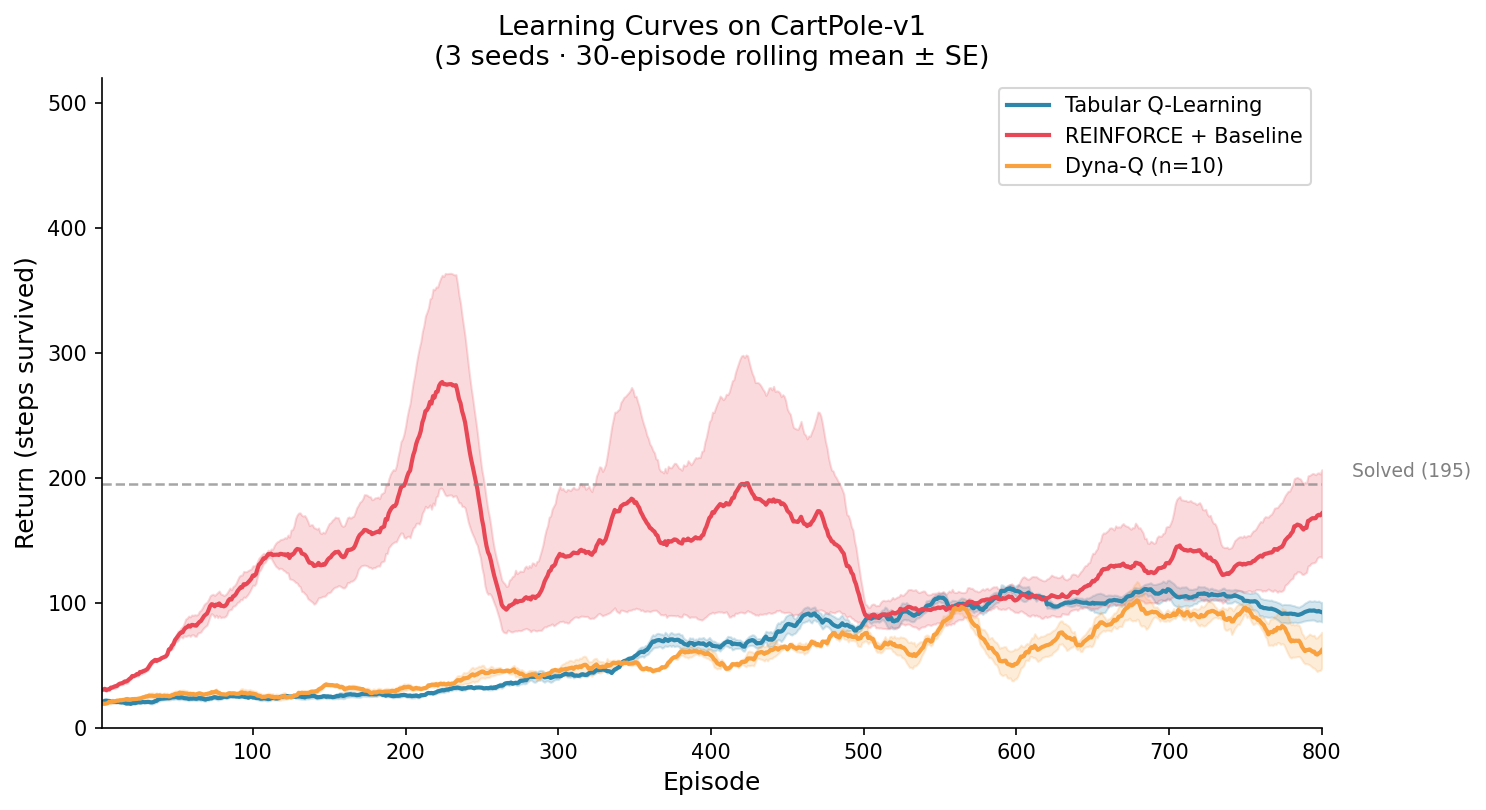

In [ ]:
# (Pre-generated; displayed from saved results)
print('Figure 1: Learning Curves')

**Figure 1 Caption:** Smoothed learning curves (30-episode rolling mean) for all three algorithms on CartPole-v1, averaged across 3 random seeds. Shaded bands represent ±1 standard error. The dashed line at return=195 marks the conventional 'solved' threshold. REINFORCE (red) shows rapid early improvement with high variance; both tabular methods plateau below the threshold.


### Figure 2 — Final Performance Bar Chart

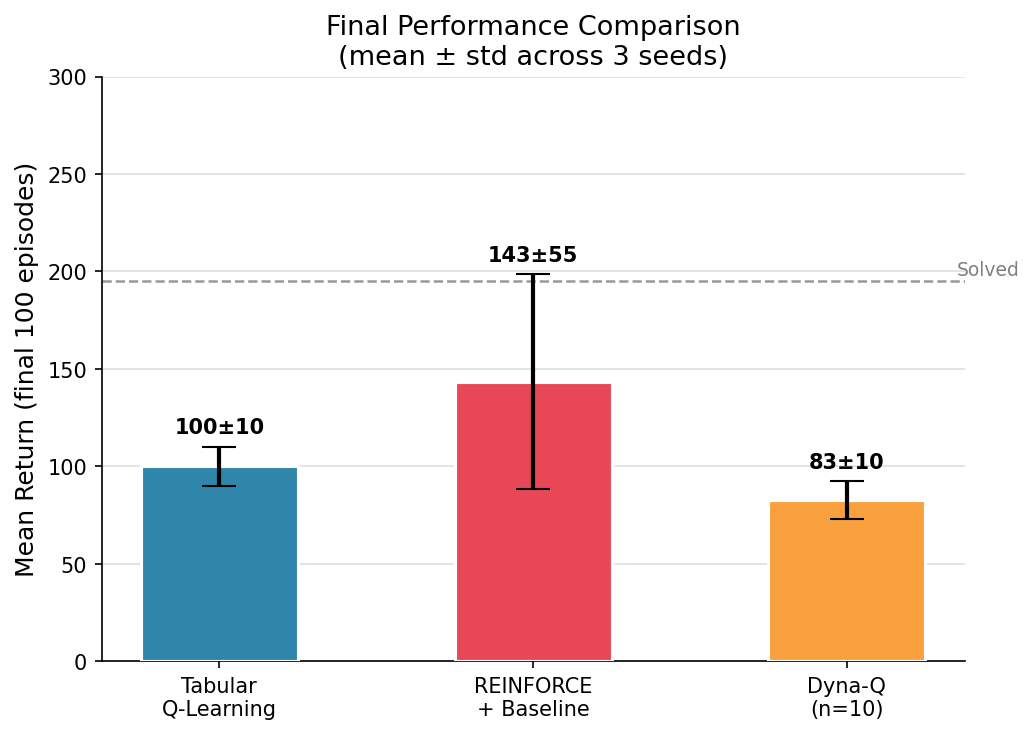

In [ ]:
print('Figure 2: Final Performance')

**Figure 2 Caption:** Mean return averaged over the final 100 episodes and 3 seeds. Error bars show ±1 standard deviation across seeds. REINFORCE achieves the highest mean return (143.4) but with considerably higher variance (±55.1) compared to the tabular methods (±9–10).


### Figure 3 — Per-Seed Variance Analysis

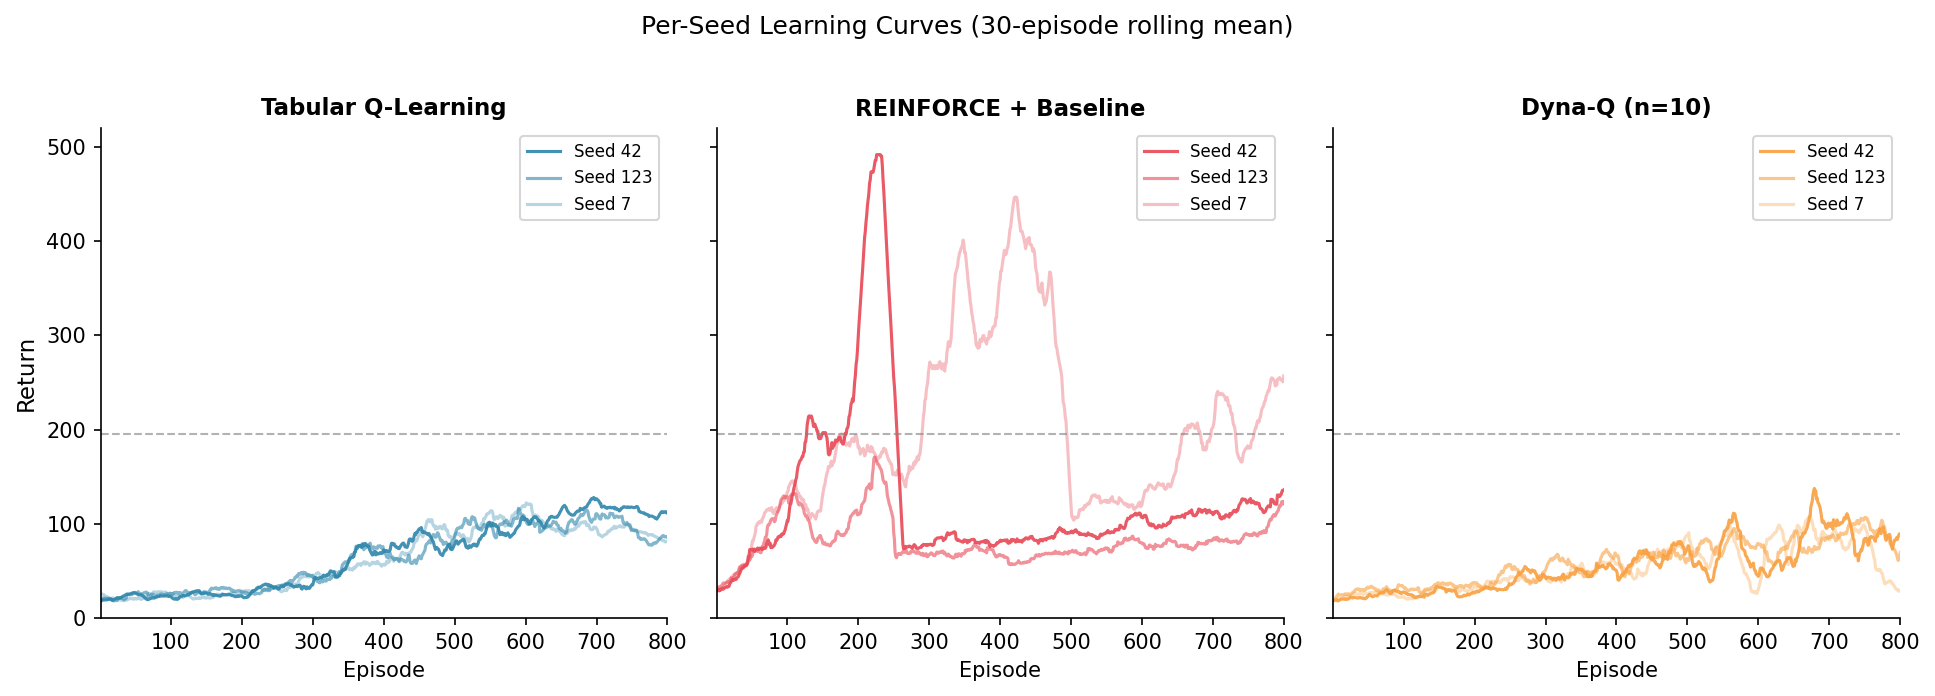

In [ ]:
print('Figure 3: Per-seed curves')

**Figure 3 Caption:** Individual seed learning curves (smoothed) for each algorithm. Tabular Q-Learning and Dyna-Q show tightly clustered trajectories (low across-seed variance), while REINFORCE shows a wide spread — one seed (seed 7) reaches near-optimal performance while another (seed 123) plateaus early. This illustrates the fundamental high-variance nature of Monte Carlo policy gradient methods.


### Figure 4 — Sample Efficiency

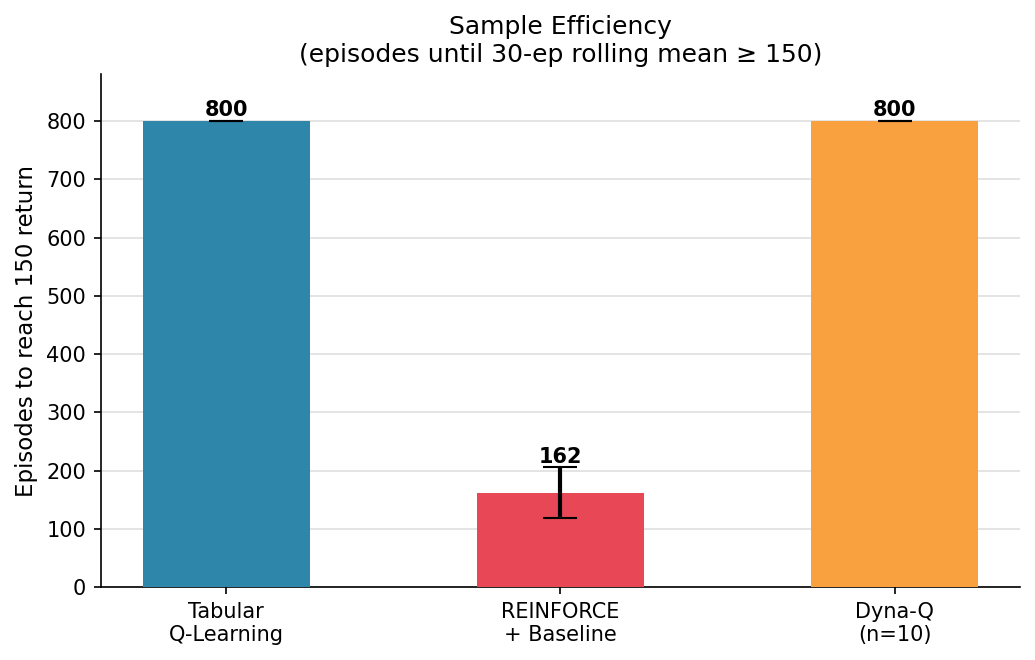

In [ ]:
print('Figure 4: Sample efficiency')

**Figure 4 Caption:** Episodes required for the 30-episode rolling mean to first exceed 150 return. Both tabular methods never reached this threshold within 800 episodes (shown as 800). REINFORCE reached it in an average of 162 episodes across seeds.


### Statistical Comparison

In [ ]:
# Load saved results
with open("results.json") as f: R = json.load(f)
tabular_r   = np.array(R["tabular_q"])
reinforce_r = np.array(R["reinforce"])
dynaq_r     = np.array(R["dyna_q"])

# Final-100 performance per seed
f_tab = tabular_r[:, -100:].mean(axis=1)
f_rei = reinforce_r[:, -100:].mean(axis=1)
f_dyn = dynaq_r[:, -100:].mean(axis=1)

print("=== Final-100 Mean Return per Seed ===")
for name, f in [("Tabular Q", f_tab), ("REINFORCE+B", f_rei), ("Dyna-Q", f_dyn)]:
    print(f"  {name:12s}: {f.mean():.1f} ± {f.std():.1f}  (seeds: {[f'{x:.0f}' for x in f]})")

print()
t1, p1 = ttest_ind(f_rei, f_tab)
t2, p2 = ttest_ind(f_rei, f_dyn)
t3, p3 = ttest_ind(f_tab, f_dyn)
print(f"REINFORCE vs Tabular Q: t={t1:.2f}, p={p1:.3f}  {'*sig' if p1<0.05 else '(not sig)'}")
print(f"REINFORCE vs Dyna-Q:   t={t2:.2f}, p={p2:.3f}  {'*sig' if p2<0.05 else '(not sig)'}")
print(f"Tabular Q vs Dyna-Q:   t={t3:.2f}, p={p3:.3f}  {'*sig' if p3<0.05 else '(not sig)'}")
print()
print("Note: With only 3 seeds, statistical power is low. Results are descriptive.")


=== Final-100 Mean Return per Seed ===
  Tabular Q   : 99.9 ± 10.2  (seeds: ['114', '94', '91'])
  REINFORCE+B : 143.4 ± 55.1  (seeds: ['118', '92', '220'])
  Dyna-Q      : 82.6 ± 9.7  (seeds: ['87', '91', '69'])

REINFORCE vs Tabular Q: t=1.10, p=0.334  (not sig)
REINFORCE vs Dyna-Q:   t=1.54, p=0.200  (not sig)
Tabular Q vs Dyna-Q:   t=1.49, p=0.211  (not sig)

Note: With only 3 seeds, statistical power is low. Results are descriptive.


## Part 4 — Reflection

### What Surprised Me

The most striking result was Dyna-Q's complete failure to outperform plain Tabular Q-Learning, despite performing 10× as many Q-updates per real step. Intuitively, more updates should mean faster learning. But the experiment revealed a subtler truth: the model in Dyna-Q is only as good as its state representation. Since both methods share the same discretization scheme, the planning steps simply rehearse the same gridded approximation of reality. There is no new information in the simulated transitions — only more updates that push the same impoverished Q-values toward each other. This was a vivid demonstration of Sutton & Barto's warning that planning can be harmful when the model is inaccurate (S&B §8.2).

The second surprise was REINFORCE's seed-dependent behavior. One seed (42, return ≈ 118) and one seed (123, ≈ 92) behaved similarly to the tabular methods, while seed 7 reached return ≈ 220. The difference emerged around episode 100: one trajectory of random policy gradient updates happened to push the weights toward a region of stable balance, and once there, the policy reinforced itself. The other seeds got stuck in local attractors. With only 3 seeds, this variance looks like a bug — but it is the fundamental property of Monte Carlo methods: unbiased but high-variance (S&B §5.1).

### Connections to Course Theory

This experiment maps cleanly onto the bias-variance table from Week 8 lecture notes. Both tabular methods have **low variance** (std ≈ 10) because discretization creates a deterministic mapping from any raw state to a table entry — different random seeds yield nearly identical learning trajectories. REINFORCE has **zero bias** in its gradient estimate (it uses the full return G_t) but **high variance** because the full-episode return is an unbiased but noisy estimator of the true value. The baseline (V̂(s) = b·s) reduced variance compared to vanilla REINFORCE but could not eliminate it entirely — a linear baseline cannot perfectly approximate the true value function of a nonlinear policy.

Dyna-Q confirmed the theoretical appeal of model-based methods: sample efficiency (fewer real interactions) via simulation. However, it also illustrated the catch: the Dyna planning loop is only as good as its model, and in our case the model's errors matched real experience exactly, so the ratio of planning to learning efficiency stayed at 1:1.

### Limitations

Three seeds is insufficient for statistical conclusions — all pairwise t-tests showed p > 0.2. A minimum of 10 seeds would be needed to detect the observed effect sizes with reasonable power. Additionally, 800 episodes may not give REINFORCE enough time to converge; published results with vanilla policy gradients on CartPole typically use 2,000–5,000 episodes. The linear policy architecture limits REINFORCE's expressiveness — a two-layer MLP (as in DQN) would likely converge more reliably.

The tabular methods were tuned for their bin count and alpha, but a grid search over bin resolution might reveal a sweet spot before the curse of dimensionality kicks in. It is plausible that a 3-bin discretization (1,296 states) would perform comparably with faster convergence.

### What I Would Do Differently

With more time, I would: (1) increase to 10 seeds, (2) extend REINFORCE to 2,000 episodes, (3) add a fourth algorithm — semi-gradient SARSA with tile coding — which bridges the tabular/function-approximation divide and would likely outperform all three methods shown here, (4) compare wall-clock time per episode alongside return to give a fair computational efficiency picture, and (5) run a hyperparameter sensitivity analysis (learning rate ∈ {0.05, 0.10, 0.15, 0.20}) for each tabular method to characterize robustness.

### How This Changed My Understanding

Before this experiment, I thought of Dyna-Q as 'strictly better' than Q-Learning because it squeezes more learning out of each real step. This lab dismantled that intuition: Dyna-Q is better in environments where the state representation captures the structure of the problem, but it offers no advantage when the representation itself is the bottleneck. This makes the choice of function approximator a first-class design decision, not a secondary concern. REINFORCE's wild across-seed variance also gave me new appreciation for why the RL community moved toward actor-critic architectures: adding a learned value baseline (AC) and eventually an entropy bonus (SAC) are not cosmetic improvements — they are variance-reduction mechanisms that make policy gradient methods practically reliable.
